## Import thư viện và chuẩn bị dữ liệu

In [ ]:
# Module helper, các thuật toán: backtracking, forward_checking, ac_3, min_conflicts đã xây dựng
from helper import Csp
from backtracking import backtracking_search
from forward_checking import forward_checking_search
from ac_3 import ac_3
from min_conflicts import min_conflicts

In [2]:
# Đọc dữ liệu từ file vn_provices.geojson
# Bao gồm các đặc điểm chính như tên tỉnh, kiểu đồ thị: MultiPolygon hoặc Polygon, và các điểm biểu thị biên giới [lon, lat]
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MatplotlibPolygon
import time, random

file_path = "vn_provices.geojson"
with open(file_path, 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)
    print("Đọc file thành công!")

Đọc file thành công!


In [3]:
# Phần chuẩn bị dữ liệu để minh họa
province_polygons = {}

all_lons = []
all_lats = []

for feature in geojson_data['features']:
    province_name = feature['properties']['adm1_name1']
    geom = feature['geometry']
    geom_type = geom['type']
    coords = geom['coordinates']
    
    if province_name not in province_polygons:
        province_polygons[province_name] = []

    def extract_single_polygon(ring_coords):
        province_polygons[province_name].append(ring_coords)
        for pt in ring_coords:
            all_lons.append(pt[0])
            all_lats.append(pt[1])

    if geom_type == "MultiPolygon":
        for polygon in coords:
            for ring in polygon:
                extract_single_polygon(ring)
                
    elif geom_type == "Polygon":
        for ring in coords:
            extract_single_polygon(ring)

if all_lons and all_lats:
    padding = 0.5 
    x_lim = (min(all_lons) - padding, max(all_lons) + padding)
    y_lim = (min(all_lats) - padding, max(all_lats) + padding)
else:
    x_lim, y_lim = (0, 0), (0, 0)

In [ ]:
# Dùng 4 màu để tô
colors = ["Red", "Yellow", "Blue", "Green"]

# 34 tỉnh thành Việt Nam sau khi sáp nhập
province_name = ['An Giang', 'Bắc Ninh', 'Cà Mau', 
                 'Cần Thơ', 'Cao Bằng', 'Đà Nẵng', 
                 'Đắk Lắk', 'Điện Biên', 'Đồng Nai', 
                 'Đồng Tháp', 'Gia Lai', 'Hà Nội', 
                 'Hà Tĩnh', 'Hải Phòng', 'Huế', 
                 'Hưng Yên', 'Khánh Hòa', 'Lai Châu', 
                 'Lâm Đồng', 'Lạng Sơn', 'Lào Cai', 
                 'Nghệ An', 'Ninh Bình', 'Phú Thọ', 
                 'Quảng Ngãi', 'Quảng Ninh', 'Quảng Trị', 
                 'Sơn La', 'Tây Ninh', 'Thái Nguyên', 
                 'Thanh Hóa', 'TP. Hồ Chí Minh', 'Tuyên Quang', 'Vĩnh Long'
                ]

# Ma trận kề, các tỉnh tiếp giáp với nhau thì ô [i][j] = 1 ngược lại bằng 0
adj_matrix = [
    [0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  #  0 An Giang
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],  #  1 Bắc Ninh
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  #  2 Cà Mau
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],  #  3 Cần Thơ
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0],  #  4 Cao Bằng
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  #  5 Đà Nẵng
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  #  6 Đắk Lắk
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],  #  7 Điện Biên
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0],  #  8 Đồng Nai
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1],  #  9 Đồng Tháp
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 10 Gia Lai
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # 11 Hà Nội
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # 12 Hà Tĩnh
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # 13 Hải Phòng
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # 14 Huế
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 15 Hưng Yên
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 16 Khánh Hòa
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # 17 Lai Châu
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 18 Lâm Đồng
    [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],  # 19 Lạng Sơn
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],  # 20 Lào Cai
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],  # 21 Nghệ An
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],  # 22 Ninh Bình
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0],  # 23 Phú Thọ
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 24 Quảng Ngãi
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 25 Quảng Ninh
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 26 Quảng Trị
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],  # 27 Sơn La
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 28 Tây Ninh
    [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],  # 29 Thái Nguyên
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],  # 30 Thanh Hóa
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # 31 TP. Hồ Chí Minh
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # 32 Tuyên Quang
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 33 Vĩnh Long
]

## Xây dựng hàm dùng Matplotlib để hiển thị kết quả sau khi chạy thuật toán (dataset bản đồ được đọc ở trên)

In [ ]:
COLOR_MAP = {
    "Red":    "#E74C3C",
    "Yellow": "#F1C40F",
    "Blue":   "#3498DB",
    "Green":  "#2ECC71",
}
 
 
def draw_colored_map(color_dict, label=""):
    '''Vẽ bản đồ 34 tỉnh thành Việt Nam dựa vào kết quả sau khi chạy thuật toán'''
    fig, ax = plt.subplots(figsize=(10, 14))
 
    for province_name, rings in province_polygons.items():
        color_name = color_dict.get(province_name, "lightgray")
        face_color = COLOR_MAP.get(color_name, color_name)
 
        for ring in rings:
            poly_patch = MatplotlibPolygon(
                ring, closed=True,
                edgecolor='black', facecolor=face_color,
                linewidth=0.5, alpha=0.8
            )
            ax.add_patch(poly_patch)
 
        if rings:
            largest_ring = max(rings, key=len)
            center_lon = sum(pt[0] for pt in largest_ring) / len(largest_ring)
            center_lat = sum(pt[1] for pt in largest_ring) / len(largest_ring)
 
            color_label = color_dict.get(province_name, "?")
            display_text = f"{province_name}\n({color_label})"
 
            ax.text(
                center_lon, center_lat,
                display_text,
                fontsize=6,
                ha='center', va='center',
                color='black',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.5)
            )
 
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_aspect('equal')
 
    title = "Bản đồ các tỉnh Việt Nam sau khi tô màu"
    if label:
        title += f"\n({label})"
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Kinh độ")
    plt.ylabel("Vĩ độ")
 
    used_colors = set(color_dict.values())
    legend_handles = [
        mpatches.Patch(
            facecolor=COLOR_MAP.get(c, c),
            edgecolor='black',
            linewidth=0.5,
            label=c
        )
        for c in sorted(used_colors)
    ]
    ax.legend(
        handles=legend_handles,
        title="Chú thích màu sắc",
        loc='lower left',
        fontsize=9,
        title_fontsize=10,
        framealpha=0.9
    )
 
    plt.tight_layout()
    plt.show()

## Thuật toán Backtracking

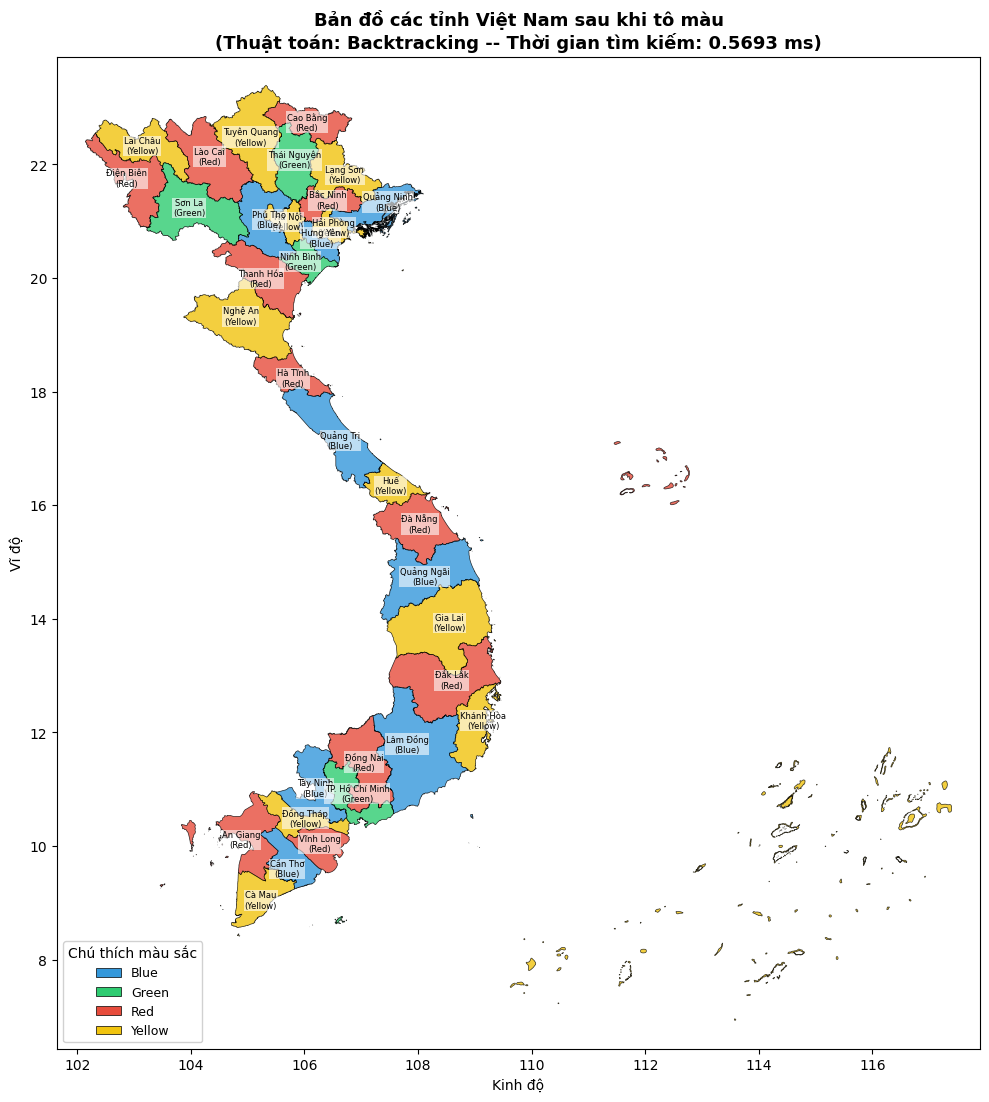

In [6]:
def show_backtracking():
    csp = Csp(vars=province_name, domain_value=[colors.copy() for _ in range(len(province_name))], constraint=adj_matrix)
    
    start = time.time()
    result = backtracking_search(csp)
    elapsed = (time.time() - start) * 1000
    

    if result is None:
        print("Không tìm thấy phép gán!!!")
    else:
        draw_colored_map(color_dict=result, label=f'Thuật toán: Backtracking -- Thời gian tìm kiếm: {elapsed:.4f} ms')

show_backtracking()

## THuật toán Forward checking

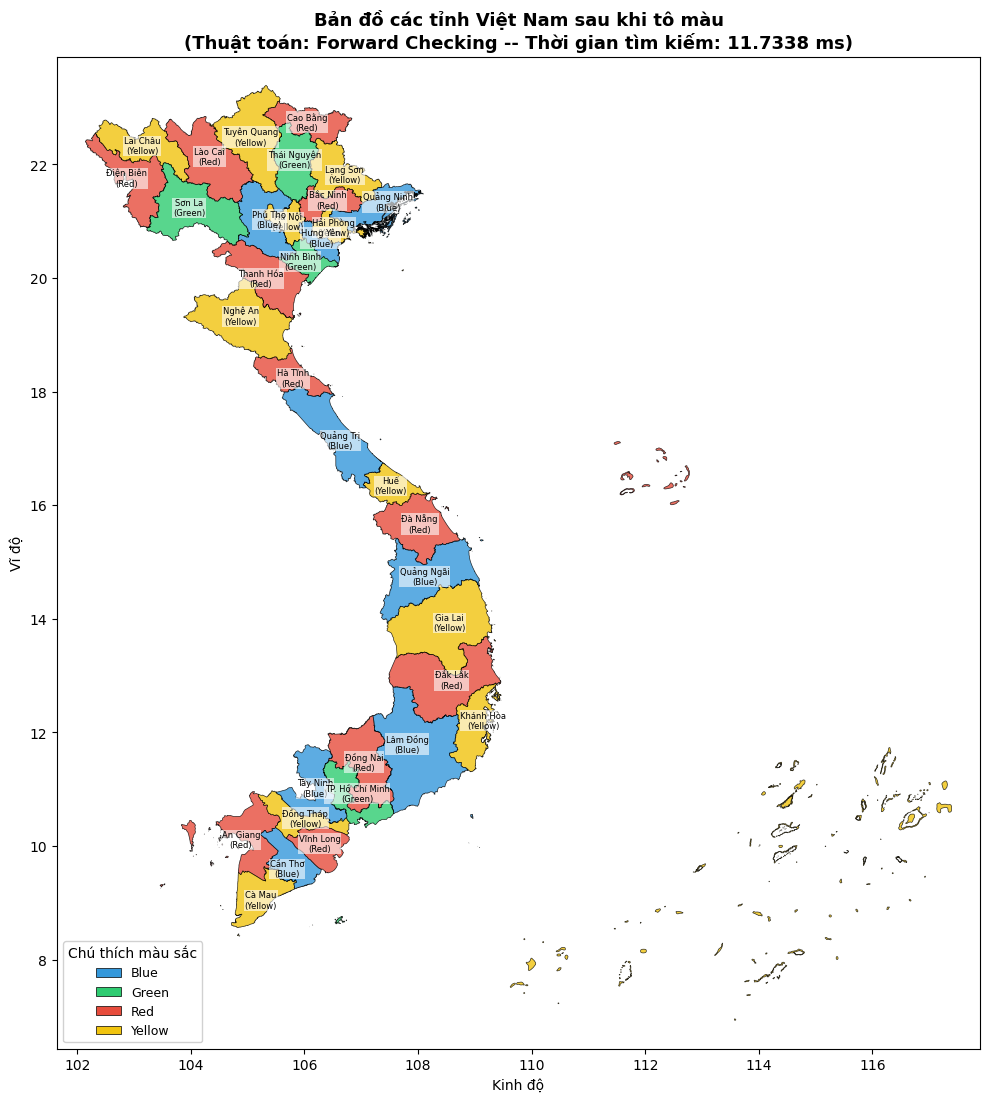

In [7]:
def show_forward_checking():
    csp = Csp(vars=province_name, domain_value=[colors.copy() for _ in range(len(province_name))], constraint=adj_matrix)
    
    start = time.time()
    result = forward_checking_search(csp)
    elapsed = (time.time() - start) * 1000
    

    if result is None:
        print("Không tìm thấy phép gán!!!")
    else:
        draw_colored_map(color_dict=result, label=f'Thuật toán: Forward Checking -- Thời gian tìm kiếm: {elapsed:.4f} ms')

show_forward_checking()

## Thuật toán AC-3 (Thu hẹp Domain) và dùng Forward Checking dựa trên kết quả AC-3 để tô màu bản đồ

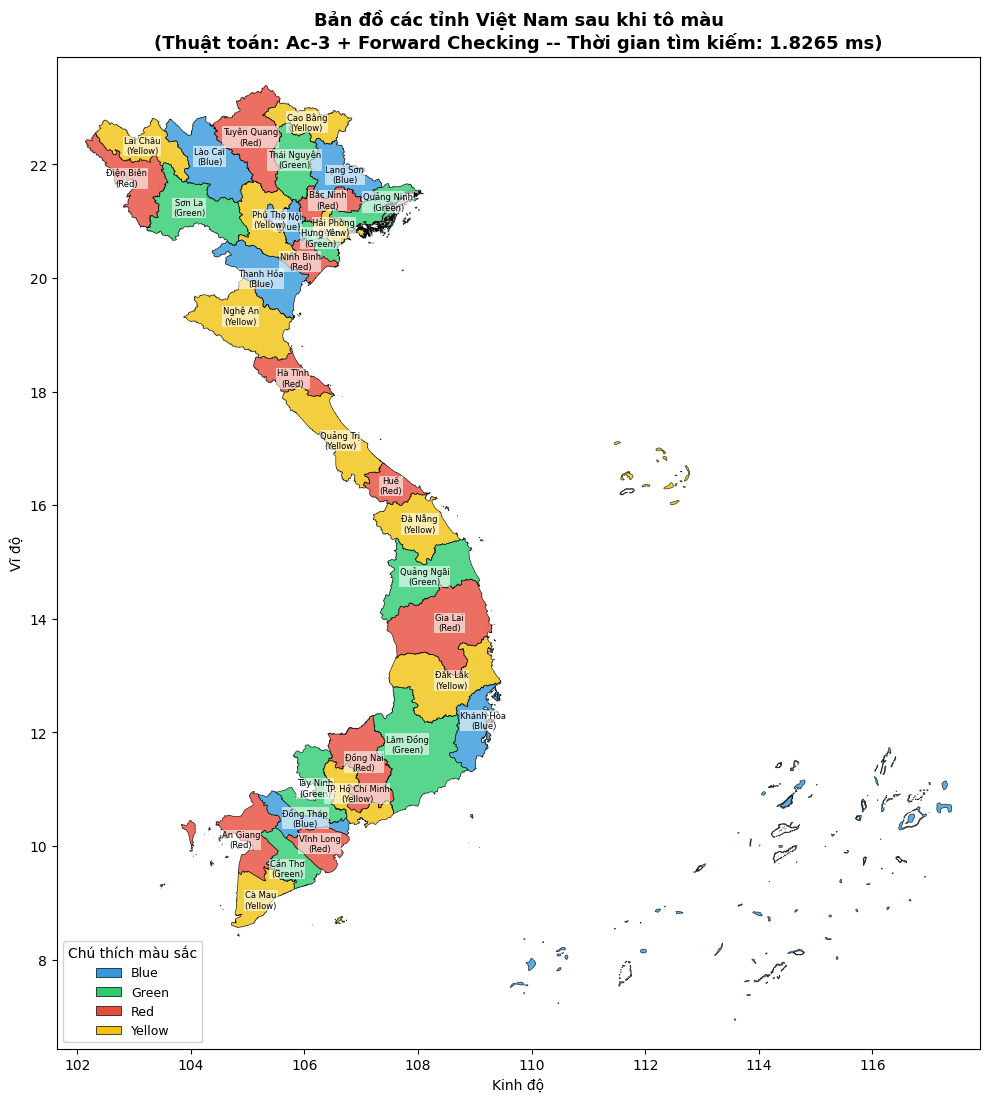

In [8]:
def show_ac_3():
    # Thu nhỏ domain các var, sau đó dùng thuật toán AC-3 để kiểm tra các cung và trả về Domain thỏa mãn ràng buộc cung
    domain = [colors.copy() for _ in range(34)]
    for x in domain:
        if random.uniform(0, 1) < 0.95:
            x.remove(random.choice(x))
        else:
            x.remove(random.choice(x))
            x.remove(random.choice(x))
            x.remove(random.choice(x))

    csp = Csp(vars=province_name, domain_value=domain, constraint=adj_matrix)
    
    start = time.time()
    result_ac_3 = ac_3(csp)
    new_domain = [[]] * len(province_name)
    for i in range(len(province_name)):
        new_domain[i] = list(result_ac_3[province_name[i]]).copy()
    
    # Dùng kết quả của AC-3 để tìm kiếm Forward checking
    result = forward_checking_search(Csp(province_name, new_domain, adj_matrix))

    elapsed = (time.time() - start) * 1000
    

    if result is None:
        print("Không tìm thấy phép gán!!!")
    else:
        draw_colored_map(color_dict=result, label=f'Thuật toán: Ac-3 + Forward Checking -- Thời gian tìm kiếm: {elapsed:.4f} ms')

show_ac_3()

## Thuật toán Min-Conficts

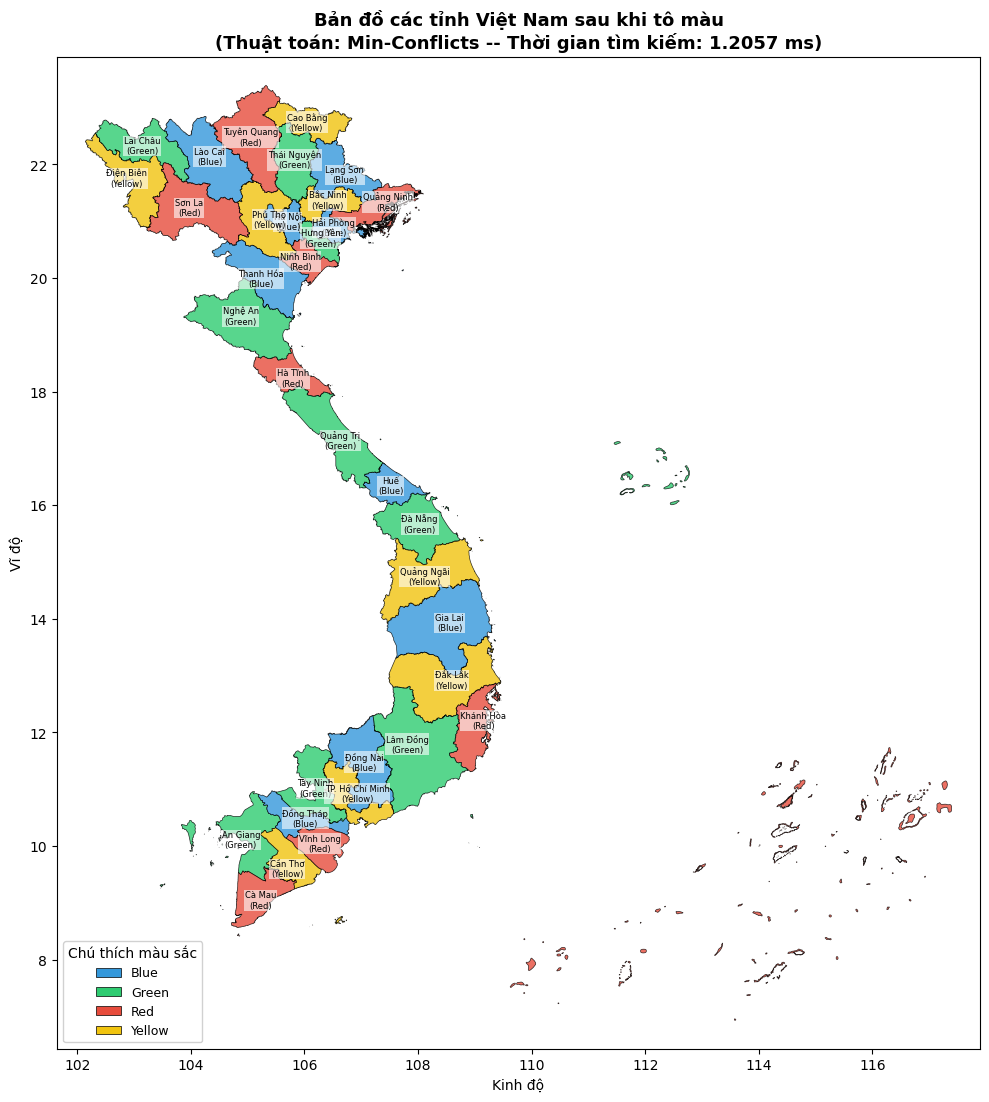

In [9]:
def show_min_conflicts():
    csp = Csp(vars=province_name, domain_value=colors, constraint=adj_matrix)
    
    start = time.time()
    result = min_conflicts(csp, max_steps=50)
    elapsed = (time.time() - start) * 1000
    

    if result is None:
        print("Không tìm thấy phép gán!!!")
    else:
        draw_colored_map(color_dict=result, label=f'Thuật toán: Min-Conflicts -- Thời gian tìm kiếm: {elapsed:.4f} ms')

show_min_conflicts()